<a href="https://colab.research.google.com/github/fcoliveira-utfpr/agrometeorologia/blob/main/07_graficos_gerais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Início - Bibliotecas**
---

In [14]:
#importando bibliotecas
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# **Carregando dados**
---

In [8]:
# =========================
# CONFIGURAÇÃO DO ARQUIVO
# =========================
nome_arquivo = "Cascavel_diarios.xlsx" ###Insira o nome do arquivo com extensão
path = "/content/"
caminho_arquivo = os.path.join(path, nome_arquivo)

# =========================
# LEITURA AUTOMÁTICA
# =========================
extensao = os.path.splitext(nome_arquivo)[1].lower()

if extensao == '.xlsx':
    df = pd.read_excel(caminho_arquivo)

elif extensao == '.csv':
    df = pd.read_csv(caminho_arquivo, sep=None, engine='python')

else:
    raise ValueError(f"Formato não suportado: {extensao}")

# =========================
# 1. REMOVER COLUNAS SEM NOME
# =========================
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# =========================
# 2. TRATAR DADOS
# =========================
for col in df.columns:
    if df[col].dtype == 'object':
        # troca vírgula por ponto
        serie = df[col].astype(str).str.replace(',', '.', regex=False)

        # tenta converter para número de forma segura
        try:
            df[col] = pd.to_numeric(serie)
        except:
            df[col] = serie  # mantém como texto se não der

# =========================

# =========================
# RESULTADO
# =========================
df

,Data,Tmin,Tmax,Chuva,UR,U2,Rs_raw,Qo_raw,Rs,Qo,...,QGcs,BOL,Rn,s,gama,ETo,Municipio,Lat,Lon,Alt
0,2025-05-12,11.60,24.81,0.03,73.61,0.10,4.7407,6.6804,17.06652,24.04944,...,18.355014,-5.129515,7.670375,0.141173,0.062328,2.204232,Cascavel,-25.029371,-53.379713,661
1,2025-05-13,14.89,26.74,0.01,75.45,0.13,4.1786,6.6401,15.04296,23.90436,...,18.244286,-4.029118,7.253102,0.160060,0.062328,2.174240,Cascavel,-25.029371,-53.379713,661
2,2025-05-14,14.50,26.95,0.04,70.42,0.12,4.5809,6.6005,16.49124,23.76180,...,18.135481,-4.842300,7.526130,0.160217,0.062328,2.264078,Cascavel,-25.029371,-53.379713,661
3,2025-05-15,12.81,24.89,0.08,65.94,0.08,4.6301,6.5614,16.66836,23.62104,...,18.028050,-5.364220,7.137050,0.144467,0.062328,2.075825,Cascavel,-25.029371,-53.379713,661
4,2025-05-16,13.67,25.47,0.01,70.95,0.07,4.0351,6.5232,14.52636,23.48352,...,17.923092,-4.213626,6.681144,0.149741,0.062328,1.955399,Cascavel,-25.029371,-53.379713,661
5,2025-05-17,15.08,27.78,0.00,65.46,0.06,3.8412,6.4858,13.82832,23.34888,...,17.820332,-3.954516,6.416724,0.166685,0.062328,1.941665,Cascavel,-25.029371,-53.379713,661
6,2025-05-18,17.20,27.02,9.89,72.43,0.08,3.3341,6.4493,12.00276,23.21748,...,17.720045,-2.988755,6.013315,0.168431,0.062328,1.827582,Cascavel,-25.029371,-53.379713,661
7,2025-05-19,16.63,26.45,0.74,80.87,0.09,4.2811,6.4142,15.41196,23.09112,...,17.623605,-4.128824,7.430146,0.163447,0.062328,2.214712,Cascavel,-25.029371,-53.379713,661
8,2025-05-20,16.04,26.89,0.21,83.22,0.11,2.8666,6.3802,10.31976,22.96872,...,17.530186,-2.153769,5.586051,0.164174,0.062328,1.676341,Cascavel,-25.029371,-53.379713,661
9,2025-05-21,16.84,27.77,2.58,78.06,0.09,3.1164,6.3470,11.21904,22.84920,...,17.438966,-2.565576,5.848704,0.171699,0.062328,1.781478,Cascavel,-25.029371,-53.379713,661


##Ver colunas

In [30]:
df.columns

Index(['Data', 'Tmin', 'Tmax', 'Chuva', 'UR', 'U2', 'Rs_raw', 'Qo_raw', 'Rs',
       'Qo', 'Tmed', 'Patm', 'NDA', 'd', 'Hn', '(d/D)²', 'BOC', 'N', 'n',
       'es_Tmax', 'es_Tmin', 'es', 'ea', 'QGcs', 'BOL', 'Rn', 's', 'gama',
       'ETo', 'Municipio', 'Lat', 'Lon', 'Alt'],
      dtype='object')

# **Gráfico de linhas**
---

/tmp/ipykernel_17730/4235998903.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(data_limpa, rotation=45, ha='right')


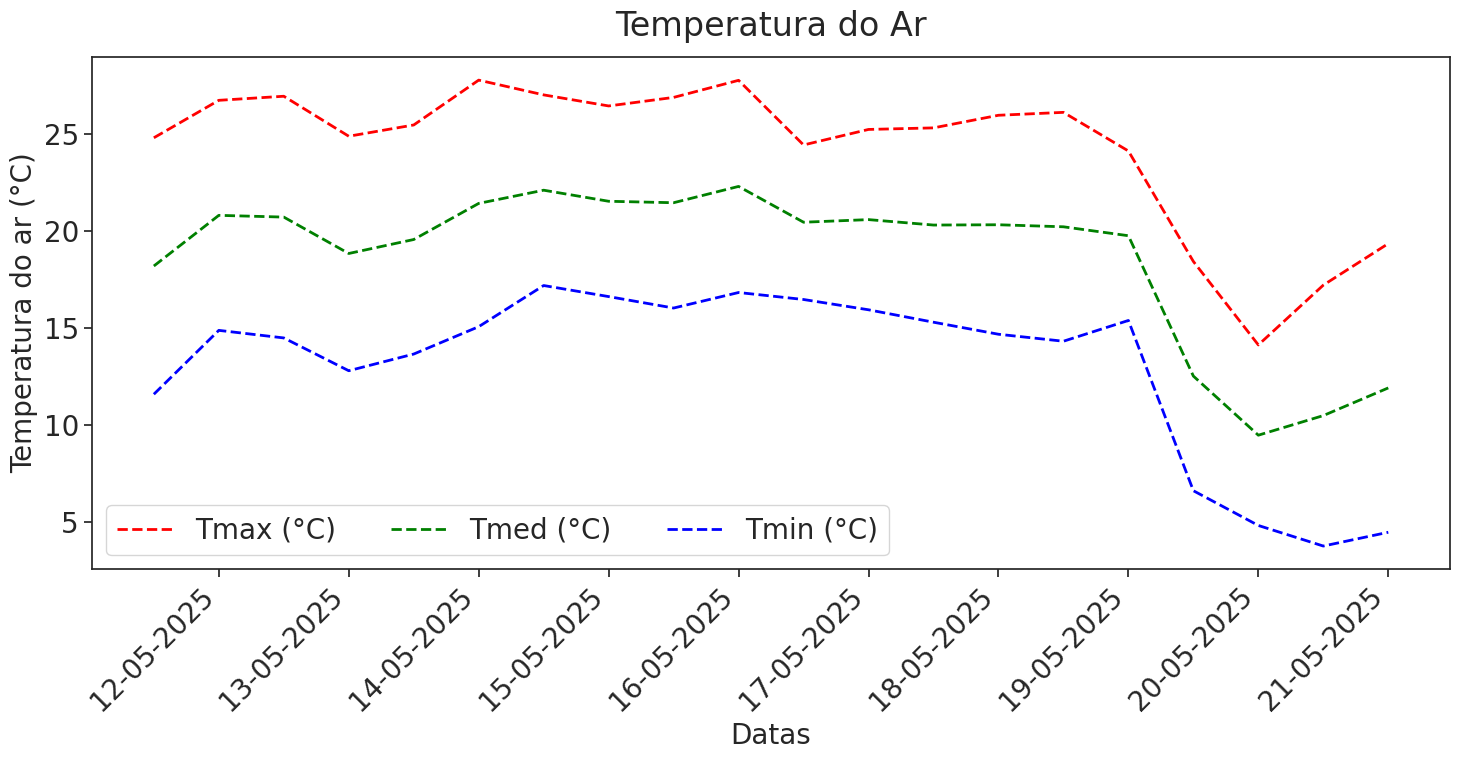

In [40]:
# --- ÁREA DE CONFIGURAÇÃO (Mude apenas aqui) ---

coluna_horizontal = 'Data' # eixo X do gráfico

# Dados e Legendas
colunas_para_plotar = ['Tmax', 'Tmed', 'Tmin']
cores = ['red', 'green', 'blue']
labels = ['Tmax (°C)', 'Tmed (°C)', 'Tmin (°C)']

# Estética Geral
tamanho_fonte_geral = 20  # Isso vai aumentar TUDO de uma vez
largura_grafico = 15
altura_grafico = 8

titulo_grafico = "Temperatura do Ar"
titulo_eixo_y = "Temperatura do ar (°C)"
titulo_eixo_x = "Datas"

# --- FIM DA ÁREA DE CONFIGURAÇÃO (Não mexa abaixo desta linha) ---
data_limpa = df[coluna_horizontal].dt.strftime('%d-%m-%Y')

# Configura as fontes globais antes de criar o gráfico
plt.rcParams.update({
    'font.size': tamanho_fonte_geral,           # Tamanho base
    'axes.titlesize': tamanho_fonte_geral + 4,   # Título do gráfico um pouco maior
    'axes.labelsize': tamanho_fonte_geral,       # Nomes dos eixos X e Y
    'xtick.labelsize': tamanho_fonte_geral,      # Números do eixo X
    'ytick.labelsize': tamanho_fonte_geral,      # Números do eixo Y
    'legend.fontsize': tamanho_fonte_geral,      # Texto da legenda
    'figure.titlesize': tamanho_fonte_geral + 6  # Título da figura
})

sns.set_style('ticks')

# Criação do gráfico
fig, ax = plt.subplots(figsize=(largura_grafico, altura_grafico))

# Loop para plotar as colunas
for col, cor, lab in zip(colunas_para_plotar, cores, labels):
    ax.plot(df[coluna_horizontal], df[col],
            color=cor,
            linewidth=2,
            linestyle='--',
            label=lab)

# Definições de títulos e eixos
ax.set_title(titulo_grafico, pad=15)
ax.set_ylabel(titulo_eixo_y)
ax.set_xlabel(titulo_eixo_x)
ax.set_xticklabels(data_limpa, rotation=45, ha='right')
ax.legend(frameon=True, ncol=len(colunas_para_plotar))

# Ajuste fino dos ticks (marcações nos eixos)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('meu_grafico.png', dpi=600, bbox_inches='tight')
plt.show()

# **Gráfico de barras**
---

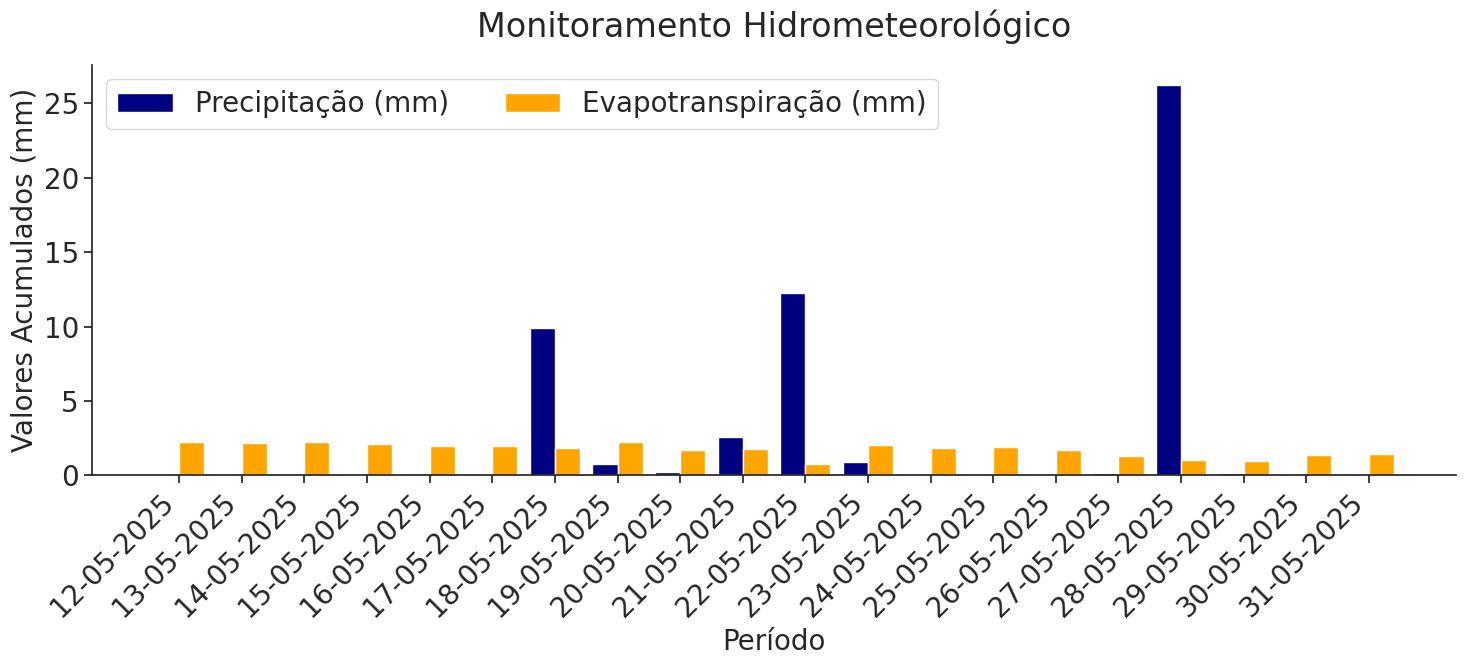

In [44]:
# --- ÁREA DE CONFIGURAÇÃO (Mude apenas aqui) ---

coluna_horizontal = 'Data'

# Sugestão para barras: 'Chuva', 'ETo'
colunas_para_plotar = ['Chuva','ETo']
cores = ['navy', 'orange']  # Azul e Laranja
labels = ['Precipitação (mm)', 'Evapotranspiração (mm)']

# Estética Geral
tamanho_fonte_geral = 18
largura_grafico = 15
altura_grafico = 7

titulo_grafico = "Monitoramento Hidrometeorológico"
titulo_eixo_y = "Valores Acumulados (mm)"
titulo_eixo_x = "Período"

# --- FIM DA ÁREA DE CONFIGURAÇÃO (Não mexa abaixo desta linha) ---
data_limpa = df[coluna_horizontal].dt.strftime('%d-%m-%Y')

plt.rcParams.update({'font.size': tamanho_fonte_geral})
sns.set_style('ticks')

fig, ax = plt.subplots(figsize=(largura_grafico, altura_grafico))

# Configuração para barras lado a lado
x = np.arange(len(df))  # Localização dos grupos (corrigido: usar len(df) em vez de len(df[data_limpa]))
largura_barra = 0.8 / len(colunas_para_plotar)

# Loop para criar as barras
for i, (col, cor, lab) in enumerate(zip(colunas_para_plotar, cores, labels)):
    posicao = x - 0.4 + (i * largura_barra) + (largura_barra / 2)
    ax.bar(posicao, df[col], width=largura_barra, color=cor, label=lab, edgecolor='white')

# Ajustes de títulos e eixos
ax.set_title(titulo_grafico, pad=20)
ax.set_ylabel(titulo_eixo_y)
ax.set_xlabel(titulo_eixo_x)

# Coloca os nomes das datas no eixo X
ax.set_xticks(x)
ax.set_xticklabels(data_limpa, rotation=45, ha='right')

ax.legend(ncol=len(colunas_para_plotar))

sns.despine()
plt.tight_layout()
plt.savefig('meu_grafico.png', dpi=600, bbox_inches='tight')
plt.show()

# **Gráfico boxplot**
---

/tmp/ipykernel_17730/3827164695.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(df[colunas_boxplot],


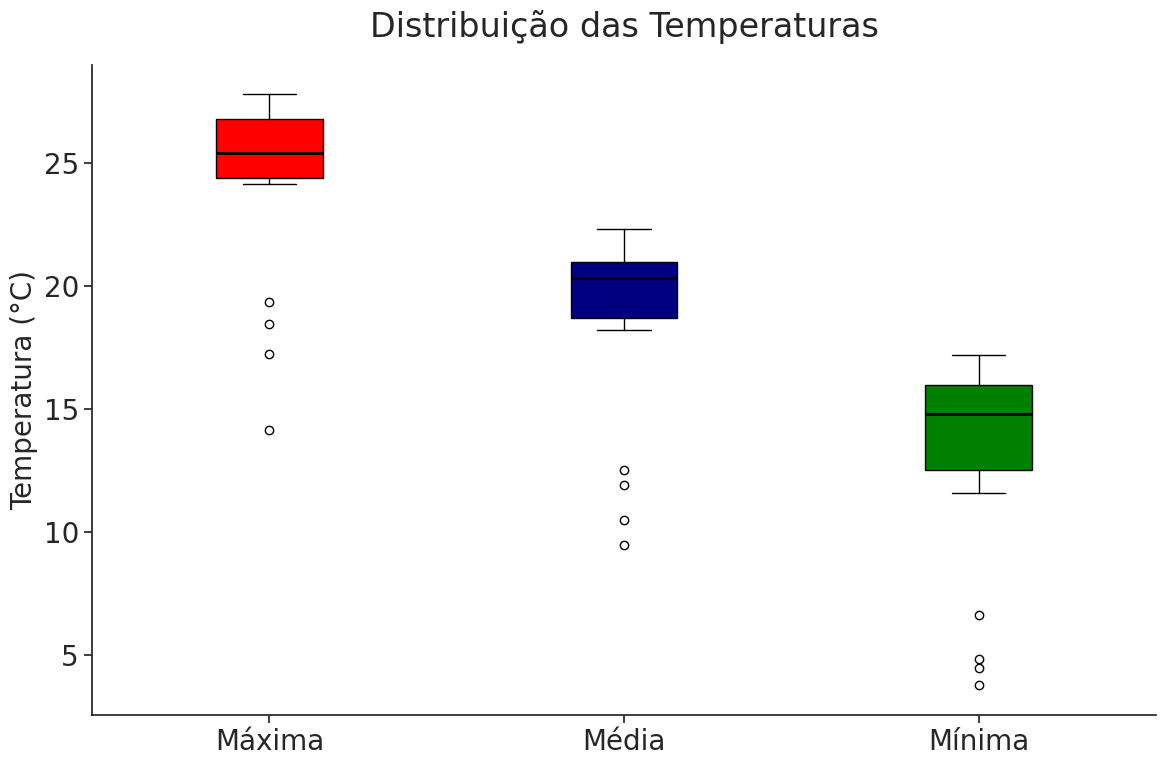

In [46]:
# --- ÁREA DE CONFIGURAÇÃO (Mude apenas aqui) ---

# Escolha as colunas numéricas que deseja comparar (ex: Temperaturas ou Umidade)
colunas_boxplot = ['Tmax', 'Tmed', 'Tmin']

cores_boxplot = ['red', 'navy', 'green'] # Vermelho, Azul, Verde
labels_eixo_x = ['Máxima', 'Média', 'Mínima']

# Estética Geral
tamanho_fonte_geral = 18
largura_grafico = 12
altura_grafico = 8

titulo_grafico = "Distribuição das Temperaturas"
titulo_eixo_y = "Temperatura (°C)"

# --- FIM DA ÁREA DE CONFIGURAÇÃO (Não mexa abaixo desta linha) ---

plt.rcParams.update({'font.size': tamanho_fonte_geral})
sns.set_style('ticks')

fig, ax = plt.subplots(figsize=(largura_grafico, altura_grafico))

# Criando o Boxplot
bplot = ax.boxplot(df[colunas_boxplot],
                   labels=labels_eixo_x,
                   patch_artist=True,
                   medianprops={'color': 'black', 'linewidth': 2})

# Aplicando as cores escolhidas em cada caixa
for patch, color in zip(bplot['boxes'], cores_boxplot):
    patch.set_facecolor(color)

# Ajustes de títulos e eixos
ax.set_title(titulo_grafico, pad=20)
ax.set_ylabel(titulo_eixo_y)

sns.despine()
plt.tight_layout()
plt.savefig('meu_grafico.png', dpi=600, bbox_inches='tight')
plt.show()

# **Gráfico heatmap de correlação**
---

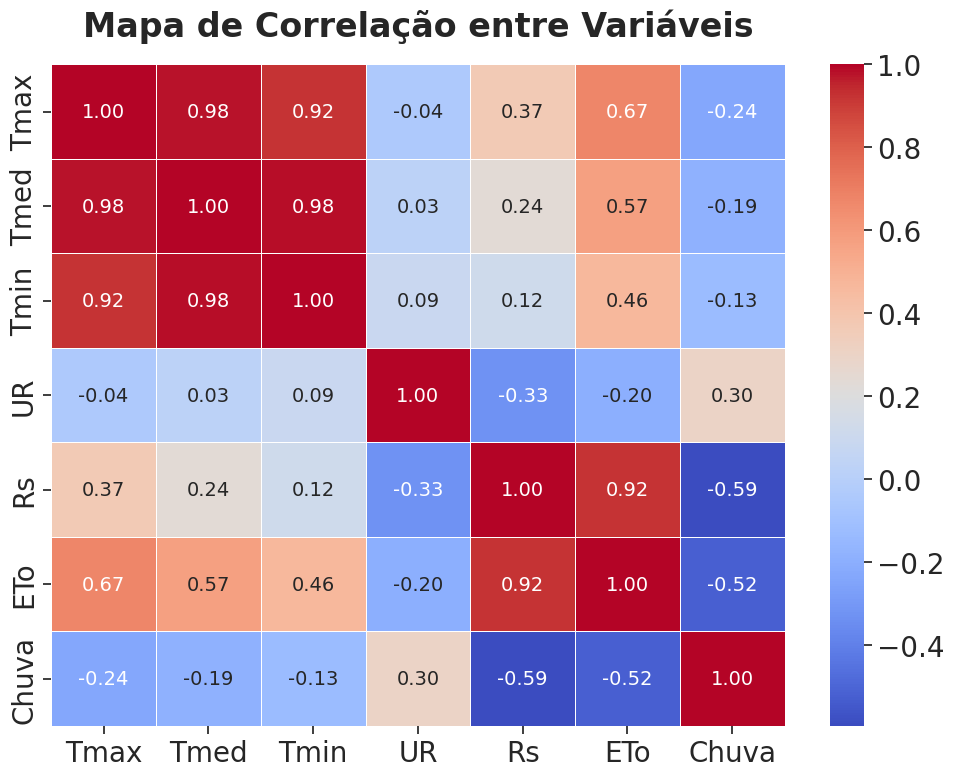

In [47]:
# --- ÁREA DE CONFIGURAÇÃO (Mude apenas aqui) ---

# Escolha as variáveis que deseja cruzar (ex: temperaturas, umidade, vento)
colunas_para_correlacao = ['Tmax', 'Tmed', 'Tmin', 'UR', 'Rs', 'ETo', 'Chuva']

# Estética Geral
tamanho_fonte_geral = 14 # Um pouco menor para caber os números dentro dos quadrados
largura_grafico = 10
altura_grafico = 8

titulo_grafico = "Mapa de Correlação entre Variáveis"
estilo_cor = "coolwarm" # Sugestões: 'YlGnBu', 'magma', 'seismic'

# --- FIM DA ÁREA DE CONFIGURAÇÃO (Não mexa abaixo desta linha) ---

# Calcula a correlação (o motor do gráfico)
correlacao = df[colunas_para_correlacao].corr()

plt.rcParams.update({'font.size': tamanho_fonte_geral})

fig, ax = plt.subplots(figsize=(largura_grafico, altura_grafico))

# Criando o Heatmap
sns.heatmap(correlacao,
            annot=True,              # Mostra os números dentro dos quadrados
            fmt=".2f",               # Arredonda para 2 casas decimais
            cmap=estilo_cor,         # Aplica a paleta de cores escolhida
            linewidths=0.5,          # Cria uma linha fina entre os quadrados
            ax=ax)

ax.set_title(titulo_grafico, pad=20, weight='bold')

plt.tight_layout()
plt.savefig('meu_grafico.png', dpi=600, bbox_inches='tight')
plt.show()